# Expressibility and entangling capability of parameterized quantum circuits for hybrid quantum-classical algorithms

In this document, we are replicating the work by S.Sim,P.D.Johnson and A.Aspuru-Guzik *Adv.Quantum.Technol.* **2** 1900070 (2019): https://arxiv.org/abs/1905.10876

Consider a parameterized quantum circuit $U(\mathbf{x})$, and define the quantity
$$f(\mathbf{x},\mathbf{y}) = |\langle 0 | U^{\dagger}(\mathbf{y})U(\mathbf{x})|0\rangle|^{2}$$
This quantity is the fidelity of the two states
$$\begin{align*}
|\psi_{\mathbf{x}}\rangle = U(\mathbf{x})|0\rangle~~&\text{and}~~|\psi_{\mathbf{y}}\rangle = U(\mathbf{y})|0\rangle:\\
|\langle \psi_{\mathbf{y}}|\psi_{\mathbf{x}}\rangle|^{2} &= |\langle 0 |U^{\dagger}(\mathbf{y})U(\mathbf{x})|0\rangle|^{2}.
\end{align*}$$

Suppose we generate a bunch of random realizations of $\mathbf{x},\mathbf{y}$. This gives us a set of random realizations of $f$; let's call that set $F = \{f_{1}, f_{2}, \cdots \}$.

To calculate the expressibility, we need to do 2 things:
* Generate a _histogram_ of the elements of $F$. The output of this histogram is a set of bins $B = \{(l_1, u_1), (l_2, u_2), \cdots \}$ where $l_{j}$ ($u_j$) denotes the lower (upper) limit of bin $j$. It also produces an empirical probability distribution function $\mathrm{Pr}_{\text{emp}}(j)$, which is simply the probability that a given value of $f$ falls in a bin $j$.
* Given the bins of the histogram, we need to compute the probability that a given fidelity value would fall into bin $j$ if the circuit generating that fidelity is drawn from a Haar-random distribution. If the circuit acts on $n$ qubits, the probability of a given fidelity value $f$ is:
$$ \mathrm{Pr}_{\text{Haar}}(f) = (N -1)*(1-f)^{N-2}~~N=2^{n}.$$
To calculate the probability over a bin of the histogram, we do an integral:
$$\mathrm{Pr}_{\text{Haar}}(j) = \int_{l_{j}}^{u_{j}}  \mathrm{Pr}_{\text{Haar}}(f) ~df =  (1-l_{j})^{N-1}  - (1-u_{j})^{N-1}$$
The expressibility is then estimated as the KL divergence between the empirically-observed probability distribution (i.e., the histogram) and the probability distribution that would result under a Haar-random unitary.
$$\text{Expr} = \mathrm{KL}(\mathrm{Pr}_{\text{emp}}|| \mathrm{Pr}_{\text{Haar}}) = \sum_{j} \mathrm{Pr}_{\text{emp}}(j)\log\left(\frac{\mathrm{Pr}_{\text{emp}}(j)}{\mathrm{Pr}_{\text{Haar}}(j)}\right)$$

## Imports

In [1]:
import os

import qiskit
from qiskit_machine_learning.algorithms import VQC
from qiskit.circuit import QuantumCircuit,Parameter, QuantumRegister, ClassicalRegister
from qiskit import transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector,partial_trace, DensityMatrix

import pennylane as qml
from pennylane import numpy as pnp
import qutip
from toqito import state_props

import numpy as np
from scipy.linalg import expm as expMatrix
import math

from ucimlrepo import fetch_ucirepo

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pdflatex

import pandas as pd

from qiskit_qc import *

from math import pi, sqrt

from scipy.special import rel_entr
from scipy.stats import entropy
from scipy.special import kl_div, rel_entr
from random import seed
from random import random,choice
import random
import cmath

## Bins

In [ ]:
def P_harr(l,u,N):
    return (1-l)**(N-1)-(1-u)**(N-1)

def bins(N_qubits):
    #Possible Bin
    bins_list=[]
    for i in range(76):
        bins_list.append((i)/75)
    #Center of the Bean
    bins_x=[]    
    for i in range(75):
        bins_x.append(bins_list[1]+bins_list[i])
    
    #Harr histogram
    P_harr_hist=[]
    for i in range(75):
        P_harr_hist.append(P_harr(bins_list[i],bins_list[i+1],2**(N_qubits)))    
    #Imaginary    
    #j=(-1)**(1/2)
    return P_harr_hist, bins_x, bins_list

## Idle Circuit

In [7]:
qasm_simulator = Aer.get_backend("qasm_simulator")

shots=10000
simulation_samples=4000
fidelity=[]    
for x in range(simulation_samples):
    th=2*pi*random()
    qr = QuantumRegister(1)
    cr = ClassicalRegister(1)
    qc = QuantumCircuit(qr, cr)
    qc.id(qr[0])
    qc.id(qr[0])
    qc.measure(qr[0],cr[0])
    
    if x==0:
        qc.draw('mpl')

    job = qasm_simulator.run(qc, shots=shots)
    result = job.result()
    count = result.get_counts()

    if '0' in count:
        ratio=count['0']/shots
    else:
        ratio=0
    fidelity.append(ratio)

P_harr_hist, bins_x, bins_list=bins(N_qubits=1)

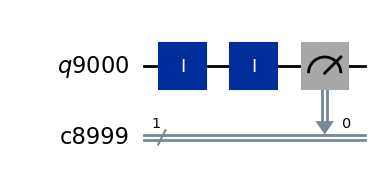

In [8]:
qc.draw('mpl')

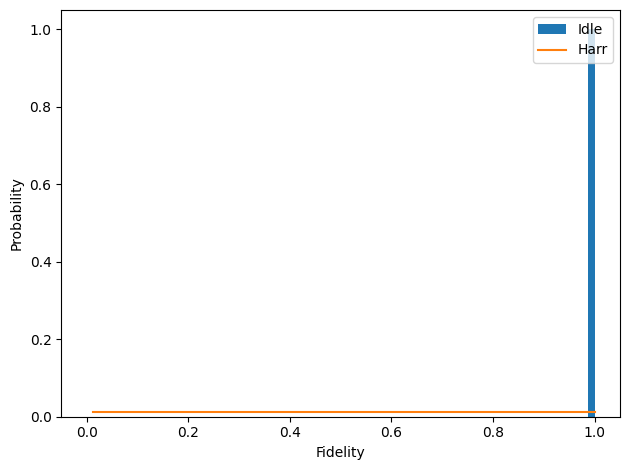

In [9]:
weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, label='Idle', range=[0, 1])
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

In [10]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('KL(P || Q): %.3f nats' % sum(kl_pq))

KL(P || Q): 4.317 nats


## Rascunho

In [ ]:
import numpy as np

def is_unitary(matrix, tol=1e-9):
    """
    Verifica se uma matriz é unitária.
    
    Uma matriz U é unitária se U†U = UU† = I, onde U† é a conjugada transposta de U.
    
    Parâmetros:
    matrix -- matriz a ser verificada (numpy array)
    tol -- tolerância para erros numéricos (float)
    
    Retorna:
    True se a matriz é unitária, False caso contrário
    """
    # Calcula a conjugada transposta da matriz
    conjugate_transpose = np.conj(matrix).T
    
    # Calcula U†U e UU†
    product1 = np.dot(conjugate_transpose, matrix)
    product2 = np.dot(matrix, conjugate_transpose)
    
    # Cria a matriz identidade do mesmo tamanho
    identity = np.eye(matrix.shape[0])
    
    # Verifica se ambos os produtos são iguais à identidade dentro da tolerância
    return (np.allclose(product1, identity, atol=tol) and 
            np.allclose(product2, identity, atol=tol))

tx = rng.random((1,NF))  # Parâmetros para tx
tw = rng2.random((1,NF))  # Parâmetros para tw
w=tw

# Simule o circuito para obter o vetor de estado
X_new=np.array(tx[0])
if np.log2(N_features)%2!=0 and np.log2(N_features)!=1:
    for k in range(2**(N_qubits-1) - N_features):
        w=np.append(w,0)
        X_new=np.append(X_new,0)
    sigmaE=np.diag(X_new)*w.T
else:
    sigmaE=np.diag(X_new)*w.T


# IQC

qc = QuantumCircuit(N_qubits)

qc.h(0)
qc.h(range(1,N_qubits))



#Montando os sigmas

matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z



#Operador Unitário
U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

# qubitstarget = [i for i in range(Ntarget)] - > Desnecessário agora, mas interessante para fazer a generalização
qc.unitary(U,qubits)

is_unitary(U)

## IQC, NF2

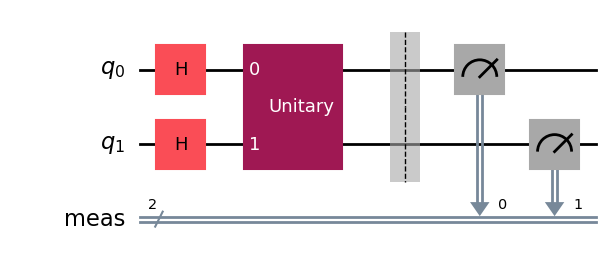

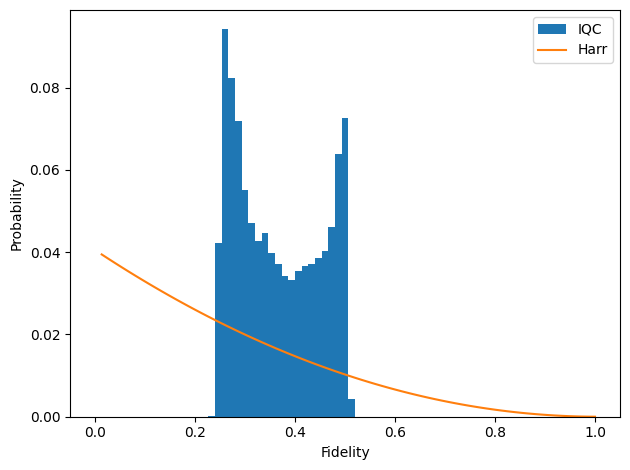

In [3]:
MODEL='IQC'
NF=2
N_qubits=math.ceil(np.log2(NF)+1) #Nqubits do circuito
string_zero='0'*N_qubits #Fazendo a String de controle para calcularmos a fidelidade do circuito
counter=0
qubits=[i for i in range(N_qubits)]

P_harr_hist, bins_x, bins_list=bins(N_qubits=N_qubits)

folder=f'NF{NF}_'+MODEL
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)

qasm_simulator = Aer.get_backend("qasm_simulator")

shots=10000
simulation_samples=5000
fidelity=[]    
for dd in range(simulation_samples):
    # Gere os parâmetros aleatórios
    tx = rng.random((1,NF))  # Parâmetros para tx
    tw = rng2.random((1,NF))  # Parâmetros para tw

    # Cria o circuito com os parâmetros fornecidos
    qc,_,_ = circuit_model(data=tx[0],contador=dd,w=tw,counter=counter,qubits=qubits,N_qubits=N_qubits,N_features=NF,model=MODEL,folder=folder,N_qubits_tgt=None,N_layers=None)

    # Simule o circuito para obter o vetor de estado
    statevector = Statevector(qc)

    count=run_qasm_counts(qc, shots, measure=True)
    
    
    if string_zero in count and '1' in count:
        ratio=count[string_zero]/shots
    elif string_zero in count and '1' not in count:
        ratio=count[string_zero]/shots
    else:
        ratio=0
    fidelity.append(ratio)

display(qc.draw('mpl'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

### Quantitative Analysis

In [4]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q): %.3f nats' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q): %.3f nats' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q): %.3f nats' %sum(kl_pq))

rel_entry(P || Q): 1.189 nats
S(P || Q): 1.189 nats
KL(P || Q): 1.189 nats


## IQC_AIL, NF2

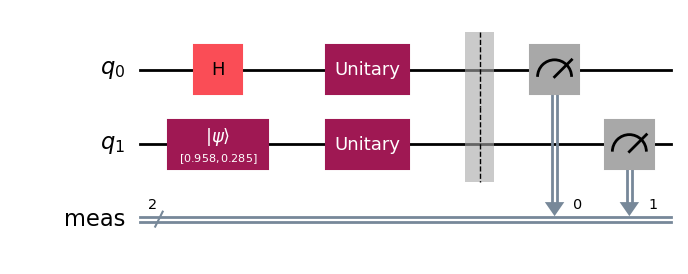

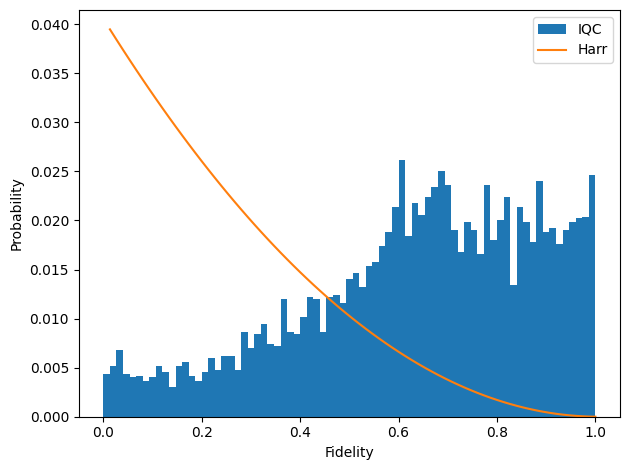

In [ ]:
MODEL='IQC_AIL'
NF=2
N_qubits=math.ceil(np.log2(NF)+1) #Nqubits do circuito
string_zero='0'*N_qubits #Fazendo a String de controle para calcularmos a fidelidade do circuito
counter=0
qubits=[i for i in range(N_qubits)]

P_harr_hist, bins_x, bins_list=bins(N_qubits=N_qubits)

folder=f'NF{NF}_'+MODEL
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)

qasm_simulator = Aer.get_backend("qasm_simulator")

shots=10000
simulation_samples=5000
fidelity=[]    
for dd in range(simulation_samples):
    # Gere os parâmetros aleatórios
    tx = rng.random((1,NF))  # Parâmetros para tx
    tw = rng2.random((1,NF))  # Parâmetros para tw
    tx=normalize_model(tx,model=MODEL,normalize_col=False,normalize_lin=True)

    # Cria o circuito com os parâmetros fornecidos
    qc,_,_ = circuit_model(data=tx[0],contador=dd,w=tw,counter=counter,qubits=qubits,N_qubits=N_qubits,N_features=NF,model=MODEL,folder=folder,N_qubits_tgt=None,N_layers=None)

    # Simule o circuito para obter o vetor de estado
    statevector = Statevector(qc)

    

    count=run_qasm_counts(qc, shots,measure=True)
    
    
    if string_zero in count and '1' in count:
        ratio=count[string_zero]/shots
    elif string_zero in count and '1' not in count:
        ratio=count[string_zero]/shots
    else:
        ratio=0
    fidelity.append(ratio)

display(qc.draw('mpl'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

### Quantitative Analysis

In [6]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q): %.3f nats' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q): %.3f nats' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q): %.3f nats' %sum(kl_pq))

rel_entry(P || Q): 1.774 nats
S(P || Q): 1.774 nats
KL(P || Q): 1.774 nats


## IQCpQ, N_qubits_tgt=2

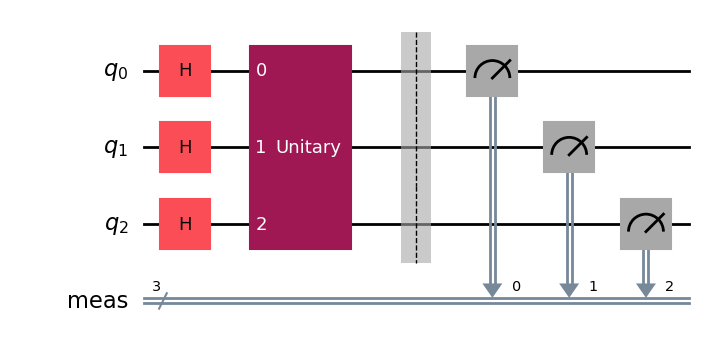

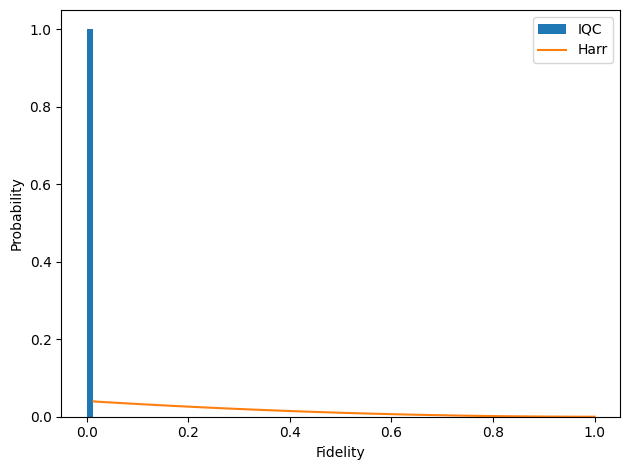

In [ ]:
MODEL='IQCpQ'
NF=2
N_qubits_tgt=2
N_qubits=math.ceil(np.log2(NF)+N_qubits_tgt)
counter=0
qubits=[i for i in range(N_qubits)]

P_harr_hist, bins_x, bins_list=bins(N_qubits=N_qubits)

folder=f'NF{NF}_'+MODEL+'_tgt2'
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)
qasm_simulator = Aer.get_backend("qasm_simulator")

string_de_zeros = '0' * (N_qubits)

shots=10000
simulation_samples=5000
fidelity=[]    
for _ in range(simulation_samples):
    tx = rng.random((1,NF))  # Parâmetros para tx
    tw = rng2.random((1,NF))  # Parâmetros para tw
    # Cria o circuito com os parâmetros fornecidos
    qc,_,_ = circuit_model(data=tx[0],contador=_,w=tw,counter=counter,qubits=qubits,N_qubits=N_qubits,N_features=NF,model=MODEL,folder=folder,N_qubits_tgt=N_qubits_tgt,N_layers=None)

    # Simule o circuito para obter o vetor de estado
    statevector = Statevector(qc)

    

    count=run_qasm_counts(qc, shots,measure=True)
    
    
    if string_de_zeros in count and '1' in count:
        ratio=count[string_de_zeros]/shots
    elif 'string_de_zeros' in count and '1' not in count:
        ratio=count[string_de_zeros]/shots
    else:
        ratio=0
    fidelity.append(ratio)

display(qc.draw('mpl'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

In [8]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q): %.3f nats' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q): %.3f nats' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q): %.3f nats' %sum(kl_pq))

rel_entry(P || Q): 3.232 nats
S(P || Q): 3.232 nats
KL(P || Q): 3.232 nats


## IQCNDsE

### Debugging

In [8]:
MODEL='IQCNDsE'
NF=3
N_qubits_tgt=1
N_qubits=math.ceil(np.log2(NF)+N_qubits_tgt)
counter=0
qubits=[i for i in range(N_qubits)]

folder=f'NF{NF}_'+MODEL+'_tgt2'
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)
qasm_simulator = Aer.get_backend("qasm_simulator")

string_de_zeros = '0' * (N_qubits)

shots=10000
simulation_samples=5000
tx = rng.random((simulation_samples,NF))  # Parâmetros para tx
w = rng2.random((simulation_samples,NF))  # Parâmetros para tw

dd=random.randrange(0, 5000)
print('tx\n',tx)
print()
print('w\n',w)
print()

qc,_,_=circuit_model(data=tx[dd],contador=_,w=w[dd],counter=counter,qubits=qubits,N_qubits=N_qubits,N_features=NF,model=MODEL,folder=folder,N_qubits_tgt=N_qubits_tgt,N_layers=None)
display(qc.draw())
#qc,_,_=circuit_model(data=data,contador=_,w=w,counter=counter,qubits=qubits,N_qubits=N_qubits,N_features=NF,model=MODEL,folder=folder,N_qubits_tgt=N_qubits_tgt,N_layers=None)
#display(qc.draw())

tx
 [[0.07813993 0.95372597 0.57418217]
 [0.67270981 0.31307208 0.39243313]
 [0.35442634 0.67604099 0.90573222]
 ...
 [0.1765485  0.70901964 0.92314085]
 [0.47918679 0.25559904 0.5943196 ]
 [0.44775723 0.41053412 0.05466515]]

w
 [[0.98998337 0.29629791 0.91149834]
 [0.89876634 0.85505351 0.15856041]
 [0.65974966 0.37989418 0.47281478]
 ...
 [0.18432628 0.53835555 0.5000543 ]
 [0.12363295 0.45791304 0.96394985]
 [0.54016223 0.99077734 0.19709424]]

sigmaE
 [[0.5186341  0.35397145 0.95266206 0.        ]
 [0.35397145 0.21329234 0.48009289 0.        ]
 [0.95266206 0.48009289 0.72728594 0.        ]
 [0.         0.         0.         0.        ]]


┌───┐┌──────────┐
q_0: ┤ H ├┤0         ├
     ├───┤│          │
q_1: ┤ H ├┤1 Unitary ├
     ├───┤│          │
q_2: ┤ H ├┤2         ├
     └───┘└──────────┘

### Código

In [12]:
NF=3
N_qubits_tgt=1
N_qubits=math.ceil(np.log2(NF)+N_qubits_tgt)
counter=0
qubits=[i for i in range(N_qubits)]
data = rng.random((1,NF))  # Parâmetros para tx
w = rng2.random((1,NF))  # Parâmetros para tw

print('data',data)
print()
print('w',w)
print()
print('np.matrix(data).T@w + (np.matrix(data).T@w).T \n', (np.matrix(data).T@w + (np.matrix(data).T@w).T))
print('\n\n')

#circuit_model(data=tx[0],contador=_,w=tw,counter=counter,qubits=qubits,N_qubits=N_qubits,N_features=NF,model=MODEL,folder=folder,N_qubits_tgt=N_qubits_tgt,N_layers=None)

X_new=data
print('X_new',X_new)
print('\n\n')
if np.log2(NF)%2!=0 and np.log2(NF)!=1:
    for k in range(2**(N_qubits-1) - NF):
        w=np.append(w,0)
        X_new=np.append(X_new,0)
    X_new=np.matrix(X_new)
    w=np.matrix(w)
    # Ensure sigmaE is hermitian
    sigmaE = X_new.T @ w + (X_new.T @ w).T
else:
    w=np.matrix(w)
    # Ensure sigmaE is hermitian
    sigmaE = X_new.T @ w + (X_new.T @ w).T

print('data',data)
print()
print('data[0]',data[0])
print()
print('w',w)
print()
print('X_new', X_new)
print()
print(f'sigmaE',sigmaE)
print()
print()


data [[0.83410601 0.09890108 0.48374514]]

w [[0.32123712 0.5790786  0.61907395]]

np.matrix(data).T@w + (np.matrix(data).T@w).T 
 [[0.53589162 0.51478364 0.6717702 ]
 [0.51478364 0.114543   0.34135354]
 [0.6717702  0.34135354 0.59894803]]



X_new [[0.83410601 0.09890108 0.48374514]]



data [[0.83410601 0.09890108 0.48374514]]

data[0] [0.83410601 0.09890108 0.48374514]

w [[0.32123712 0.5790786  0.61907395 0.        ]]

X_new [[0.83410601 0.09890108 0.48374514 0.        ]]

sigmaE [[0.53589162 0.51478364 0.6717702  0.        ]
 [0.51478364 0.114543   0.34135354 0.        ]
 [0.6717702  0.34135354 0.59894803 0.        ]
 [0.         0.         0.         0.        ]]




sigmaE
 [[0.15721396 0.18804925]
 [0.18804925 0.20187188]]
sigmaE
 [[0.08596809 0.11399104]
 [0.11399104 0.1474105 ]]
sigmaE
 [[0.21672166 0.73630126]
 [0.73630126 0.24598408]]
sigmaE
 [[0.35924172 0.36199077]
 [0.36199077 0.34986985]]
sigmaE
 [[0.03852843 0.0813754 ]
 [0.0813754  0.05943868]]
sigmaE
 [[0.14692281 0.38917123]
 [0.38917123 0.37396367]]
sigmaE
 [[1.16408033 0.51258861]
 [0.51258861 0.21768198]]
sigmaE
 [[0.12729728 0.28355867]
 [0.28355867 0.32154521]]
sigmaE
 [[0.20120962 0.52958786]
 [0.52958786 0.09295495]]
sigmaE
 [[0.02534812 0.02953348]
 [0.02953348 0.01303489]]
sigmaE
 [[1.18507653 0.85861668]
 [0.85861668 0.31154064]]
sigmaE
 [[0.83349134 0.73029544]
 [0.73029544 0.32250487]]
sigmaE
 [[1.39410918 0.61938844]
 [0.61938844 0.15191441]]
sigmaE
 [[0.11710977 0.27830255]
 [0.27830255 0.34681467]]
sigmaE
 [[0.06163554 0.27915314]
 [0.27915314 0.54226319]]
sigmaE
 [[0.39590356 0.66651023]
 [0.66651023 0.04997495]]
sigmaE
 [[0.39711668 0.48820661]
 [0.48820661 0.53654589

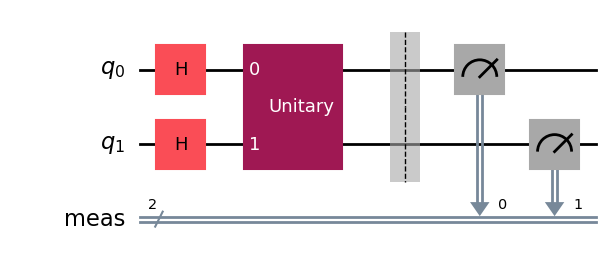

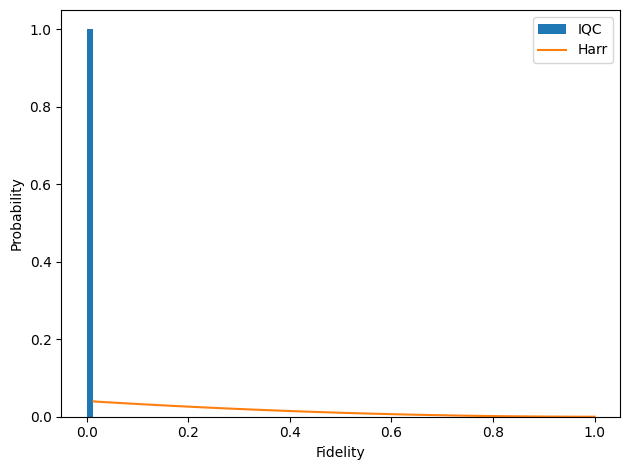

In [ ]:
MODEL='IQCNDsE'
NF=2
N_qubits_tgt=1
N_qubits=math.ceil(np.log2(NF)+N_qubits_tgt)
counter=0
qubits=[i for i in range(N_qubits)]

P_harr_hist, bins_x, bins_list=bins(N_qubits=N_qubits)

folder=f'NF{NF}_'+MODEL+'_tgt2'
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)
qasm_simulator = Aer.get_backend("qasm_simulator")

string_de_zeros = '0' * (N_qubits)

shots=10000
simulation_samples=5000
tx = rng.random((simulation_samples,NF))  # Parâmetros para tx
tw = rng2.random((simulation_samples,NF))  # Parâmetros para tw

fidelity=[]    
for ii in range(simulation_samples):
    
    # Cria o circuito com os parâmetros fornecidos
    qc,_,_ = circuit_model(data=tx[ii],contador=_,w=tw[ii],counter=counter,qubits=qubits,N_qubits=N_qubits,N_features=NF,model=MODEL,folder=folder,N_qubits_tgt=N_qubits_tgt,N_layers=None)

    # Simule o circuito para obter o vetor de estado
    statevector = Statevector(qc)

    

    count=run_qasm_counts(qc, shots,measure=True)
    
    
    if string_de_zeros in count and '1' in count:
        ratio=count[string_de_zeros]/shots
    elif 'string_de_zeros' in count and '1' not in count:
        ratio=count[string_de_zeros]/shots
    else:
        ratio=0
    fidelity.append(ratio)

display(qc.draw('mpl'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

In [14]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q): %.3f nats' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q): %.3f nats' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q): %.3f nats' %sum(kl_pq))

rel_entry(P || Q): 3.232 nats
S(P || Q): 3.232 nats
KL(P || Q): 3.232 nats


## 4-qubit Circuit bagmk

In [10]:
def circuit9(qc,qr,theta,L,repeat):
    #circuit 9
    #theta is list of the parameters
    #theta length is (4)L
    #L is the number of repeatation
    
    # repeat will conjugate the first part and add next the the circuit for expressibility
    # 0:No, 1: Repeat    
    


    count=0
    for l in range(L):

        for i in range(4):
            qc.h(qr[i])

        qc.cz(qr[3],qr[2])
        qc.cz(qr[2],qr[1])
        qc.cz(qr[1],qr[0])
        
        for i in range(4):
            qc.rx(theta[count],qr[i])
            count=count+1
        
            
    if repeat!=0:             
        qc.barrier(qr)
    
        
        for l in range(L):
            for i in range(4):
                qc.rx(theta[count],qr[i])
                count=count+1
                
            qc.cz(qr[1],qr[0]) 
            qc.cz(qr[2],qr[1])
            qc.cz(qr[3],qr[2])
            
                 
        
            for i in range(4):
                qc.h(qr[i])                  
     
    return qc

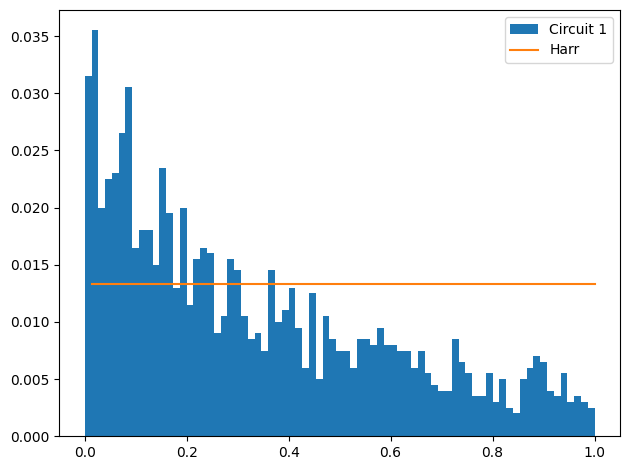

In [ ]:
backend = Aer.get_backend('qasm_simulator')
nshot=1000
nparam=2000
fidelity=[]    
for x in range(nparam):
    qr = QuantumRegister(4)
    cr = ClassicalRegister(4)
    qc = QuantumCircuit(qr, cr)
    
    theta=[];
    for y in range(80):
        theta.append(2*pi*random())
    
    qc=circuit9(qc,qr,theta,3,1)
    
    
    qc.measure(qr[:],cr[:])
    job = qasm_simulator.run(qc, shots=shots)
    result = job.result()
    count = result.get_counts()

    if '0000' in count and '1' in count:
        ratio=count['0000']/nshot
    elif '0000' in count and '1' not in count:
        ratio=count['0000']/nshot
    else:
        ratio=0
    
    fidelity.append(ratio)

display(qc.draw('mpl'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='Circuit 1')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.show()

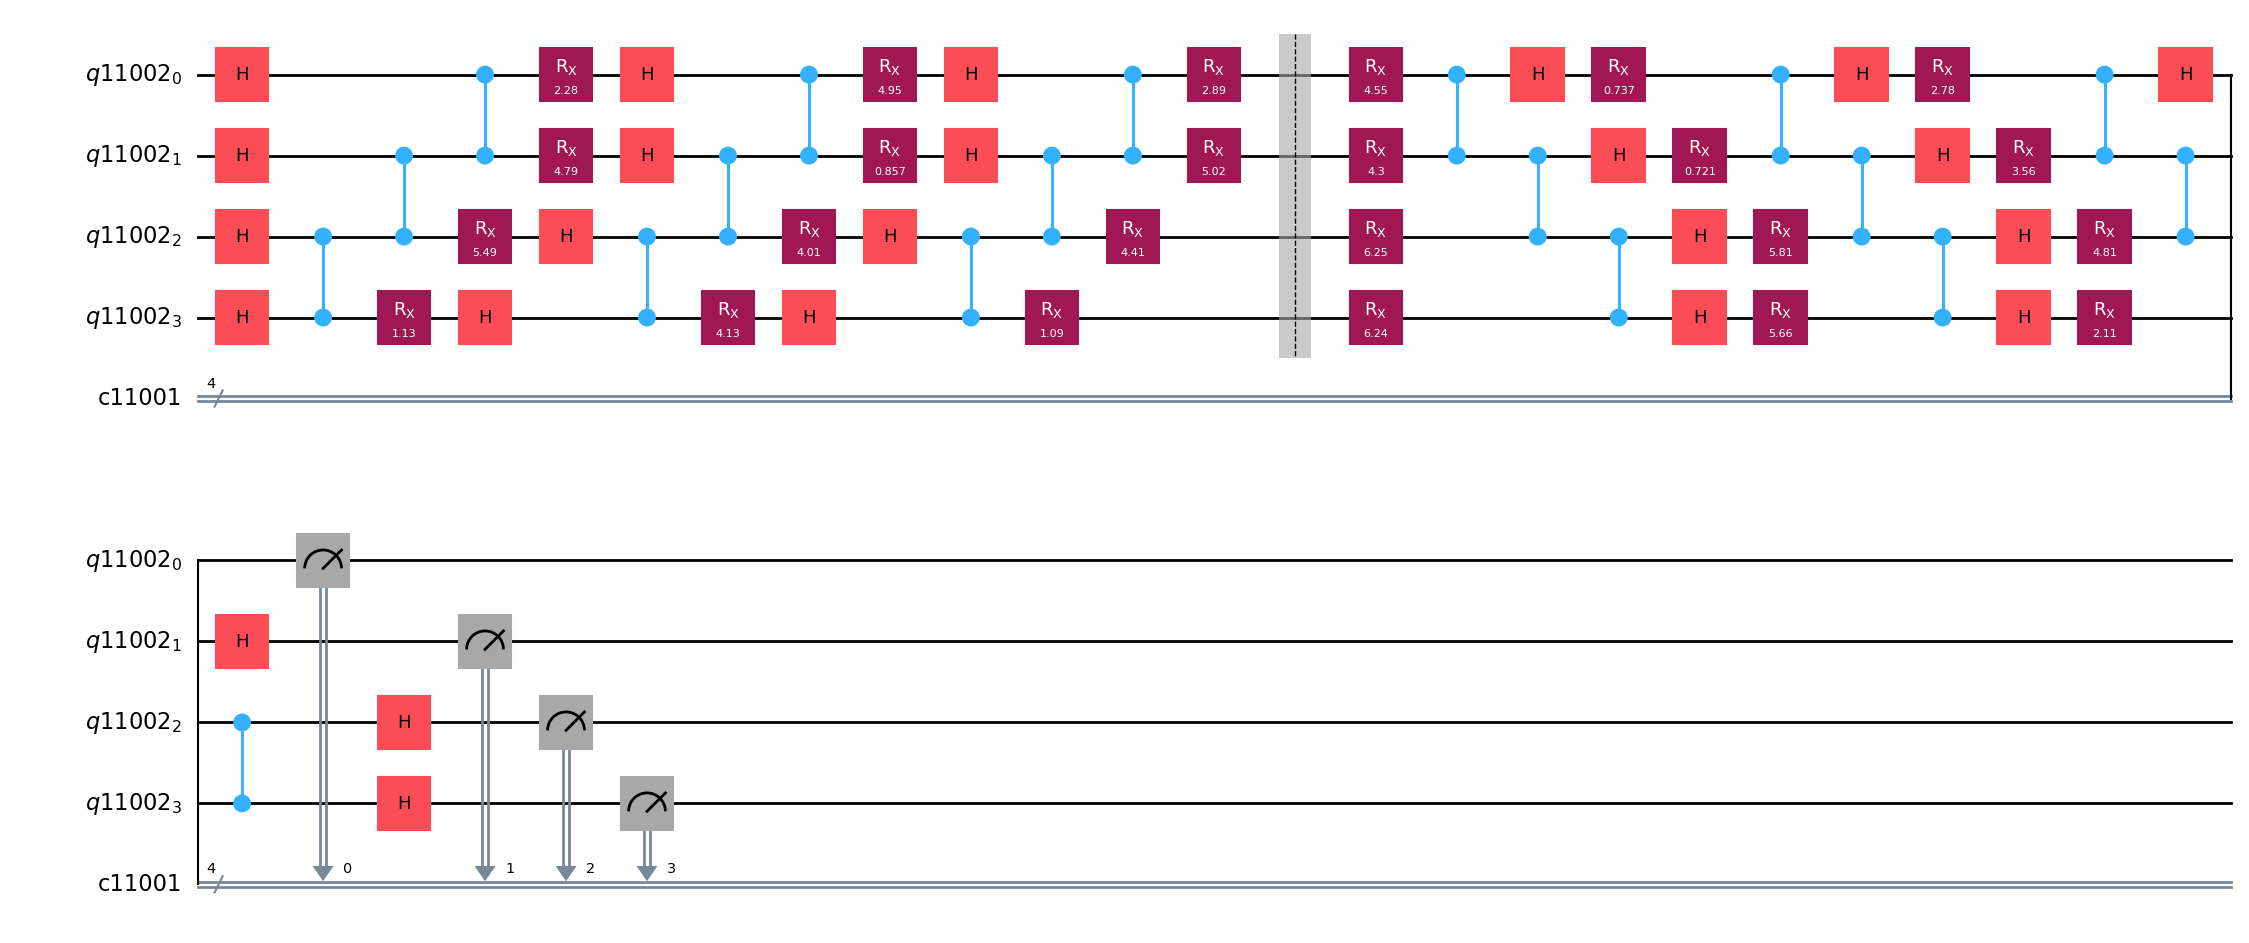

In [13]:
qc.draw('mpl')